# 🚀 Ứng dụng Deep Q-Network (DQN) vào môi trường LunarLander-v3

## Bài tập lớn cuối kỳ - Học tăng cường (Reinforcement Learning)

| Thông tin | Chi tiết |
|---|---|
| **Sinh viên** | [Họ và tên] |
| **MSSV** | [Mã số sinh viên] |
| **Giảng viên** | [Tên giảng viên] |
| **Môn học** | Học tăng cường |
| **Ngày** | Tháng 4, 2026 |

---

## 📋 Mục lục

1. **Giới thiệu bài toán** — Mô tả môi trường LunarLander-v3
2. **Cơ sở lý thuyết** — Q-Learning, DQN và các biến thể
3. **Cài đặt thuật toán** — Kiến trúc mạng, Replay Buffer, Agent
4. **Thí nghiệm** — Huấn luyện 4 biến thể DQN
5. **So sánh và phân tích kết quả** — Learning curves, bảng metrics
6. **Đánh giá Agent** — Kiểm tra hiệu suất agent
7. **Kết luận** — Tổng kết và hướng phát triển
8. **Tài liệu tham khảo**

In [16]:
# Cài đặt thư viện (bỏ comment nếu cần)
# !pip install gymnasium[box2d] torch numpy matplotlib pandas tqdm

import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
import time
import pygame
from collections import deque, namedtuple
from tqdm.notebook import tqdm
import time, os, warnings
warnings.filterwarnings('ignore')

# Cấu hình đồ thị chuyên nghiệp
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 12,
                     'axes.titlesize': 14, 'axes.labelsize': 12})

# Thiết bị tính toán
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Thiết bị: {device}")
print(f"📦 PyTorch: {torch.__version__}  |  Gymnasium: {gym.__version__}")

🖥️  Thiết bị: cuda:0
📦 PyTorch: 2.6.0+cu124  |  Gymnasium: 1.2.3


In [17]:
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules or os.environ.get("COLAB_RELEASE_TAG") is not None

if IN_COLAB:
    print("Detected Google Colab: installing Box2D dependencies...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "pip", "setuptools", "wheel"])
    subprocess.check_call(["bash", "-lc", "apt-get update -qq && apt-get install -y -qq swig"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gymnasium[box2d]", "box2d-py", "pygame"])
    print("Colab Box2D dependencies installed. If Gymnasium still cannot import Box2D, restart the runtime and rerun this cell.")
else:
    print("Local environment detected: using existing Python packages.")

Local environment detected: using existing Python packages.


---
## 1. Giới thiệu bài toán

### 1.1 Tổng quan

**Reinforcement Learning (RL)** là nhánh của Machine Learning trong đó agent học cách hành động bằng cách tương tác với môi trường và nhận phần thưởng. Mục tiêu: tìm **chính sách tối ưu** $\pi^*$ để tối đa hóa tổng phần thưởng tích lũy.

Bài tập này áp dụng **Deep Q-Network (DQN)** và các biến thể vào môi trường **LunarLander-v3**.

### 1.2 Môi trường LunarLander-v3

LunarLander-v3 mô phỏng bài toán hạ cánh tàu vũ trụ lên Mặt Trăng. Agent điều khiển động cơ đẩy để hạ cánh an toàn vào vùng đáp.

In [18]:
# Khởi tạo và khám phá môi trường
env = gym.make('LunarLander-v3')
state, info = env.reset(seed=42)

print("=" * 60)
print("📐 THÔNG TIN MÔI TRƯỜNG LUNARLANDER-V3")
print("=" * 60)
print(f"\n🔹 State Space:  {env.observation_space} ({env.observation_space.shape[0]} chiều)")
print(f"🔹 Action Space: {env.action_space} ({env.action_space.n} hành động rời rạc)")
print(f"🔹 Max Steps:    {env.spec.max_episode_steps}")
print(f"\n🔹 Trạng thái mẫu: {np.round(state, 3)}")
env.close()

📐 THÔNG TIN MÔI TRƯỜNG LUNARLANDER-V3

🔹 State Space:  Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32) (8 chiều)
🔹 Action Space: Discrete(4) (4 hành động rời rạc)
🔹 Max Steps:    1000

🔹 Trạng thái mẫu: [ 0.002  1.418  0.233  0.32  -0.003 -0.053  0.     0.   ]


### 1.3 Không gian trạng thái và hành động

#### Trạng thái (State) — 8 chiều liên tục:

| Chỉ số | Biến | Mô tả |
|:---:|---|---|
| 0 | $x$ | Tọa độ ngang |
| 1 | $y$ | Tọa độ dọc |
| 2 | $v_x$ | Vận tốc ngang |
| 3 | $v_y$ | Vận tốc dọc |
| 4 | $\theta$ | Góc nghiêng |
| 5 | $\omega$ | Vận tốc góc |
| 6 | $l_{left}$ | Chân trái chạm đất (bool) |
| 7 | $l_{right}$ | Chân phải chạm đất (bool) |

#### Hành động (Action) — 4 giá trị rời rạc:

| Giá trị | Hành động |
|:---:|---|
| 0 | Không làm gì |
| 1 | Bật động cơ trái |
| 2 | Bật động cơ chính (đẩy lên) |
| 3 | Bật động cơ phải |

#### Phần thưởng (Reward):
- Hạ cánh thành công: **+100 ~ +140** · Mỗi chân chạm đất: **+10**
- Va chạm/rơi: **−100** · Động cơ chính: **−0.3/frame** · Động cơ phụ: **−0.03/frame**
- **Solved** khi avg reward ≥ 200 trong 100 episode liên tiếp

---
## 2. Cơ sở lý thuyết

### 2.1 Reinforcement Learning & Q-Learning

Agent tương tác: tại bước $t$, quan sát $s_t$, thực hiện $a_t$, nhận $r_t$, chuyển sang $s_{t+1}$.

**Hàm giá trị hành động:**
$$Q^{\pi}(s, a) = \mathbb{E}_{\pi}\left[\sum_{k=0}^{\infty} \gamma^k r_{t+k+1} \;\middle|\; s_t = s, a_t = a\right]$$

**Phương trình Bellman tối ưu:**
$$Q^*(s, a) = \mathbb{E}\left[r + \gamma \max_{a'} Q^*(s', a') \;\middle|\; s, a\right]$$

**Cập nhật Q-Learning:**
$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\right]$$

trong đó $\gamma \in [0,1]$ là discount factor, $\alpha$ là learning rate.

### 2.2 Deep Q-Network (DQN)

Với state space liên tục, ta dùng **neural network** $Q(s, a; \theta)$ xấp xỉ hàm Q.

**Loss function:**
$$\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}}\left[\left(y^{DQN} - Q(s, a; \theta)\right)^2\right]$$

$$y^{DQN} = r + \gamma \max_{a'} Q(s', a'; \theta^{-})$$

#### Hai kỹ thuật cốt lõi:

**a) Experience Replay:**
- Lưu $(s, a, r, s', done)$ vào buffer $\mathcal{D}$, lấy minibatch ngẫu nhiên để train
- Phá vỡ tương quan giữa mẫu liên tiếp, tái sử dụng dữ liệu

**b) Target Network $\theta^-$:**
- Mạng riêng để tính target, cập nhật mềm:
$$\theta^{-} \leftarrow \tau \cdot \theta + (1 - \tau) \cdot \theta^{-}$$
- Ổn định huấn luyện, tránh dao động

### 2.3 Double DQN (van Hasselt et al., 2016)

**Vấn đề:** Toán tử $\max$ trong DQN gây **overestimation** Q-values.

**Giải pháp:** Tách **chọn hành động** (local network) và **đánh giá giá trị** (target network):

$$a^* = \arg\max_{a'} Q(s', a'; \theta) \quad \text{← mạng local chọn}$$

$$y^{DDQN} = r + \gamma \cdot Q(s', a^*; \theta^{-}) \quad \text{← mạng target đánh giá}$$

| | Chọn hành động | Đánh giá |
|---|---|---|
| **DQN** | $\theta^-$ | $\theta^-$ |
| **Double DQN** | $\theta$ | $\theta^-$ |

### 2.4 Dueling DQN (Wang et al., 2016)

Phân tách Q thành **Value** $V(s)$ và **Advantage** $A(s,a)$:

$$Q(s, a) = V(s; \beta) + A(s, a; \alpha) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s, a'; \alpha)$$

**Kiến trúc:**
```
State → FC1 → FC2 ─┬─→ Value Stream   → V(s)
                    └─→ Advantage Stream → A(s,a) → Q(s,a)
```

**Lợi ích:** Học giá trị trạng thái hiệu quả mà không cần thử mọi hành động. Hữu ích khi nhiều hành động tương đương.

### 2.5 D3QN — Double Dueling DQN

Kết hợp **cả hai** kỹ thuật Double DQN + Dueling DQN:

| Thuật toán | Double | Dueling | Đặc điểm |
|---|:---:|:---:|---|
| **Vanilla DQN** | ❌ | ❌ | Baseline |
| **Double DQN** | ✅ | ❌ | Giảm overestimation |
| **Dueling DQN** | ❌ | ✅ | Học V(s) hiệu quả |
| **D3QN** | ✅ | ✅ | Kết hợp ưu điểm |

---
## 3. Cài đặt thuật toán

### 3.1 Siêu tham số (Hyperparameters)

In [19]:
# ===================== SIÊU THAM SỐ =====================
BUFFER_SIZE = int(1e5)   # Kích thước Replay Buffer
BATCH_SIZE = 64          # Kích thước minibatch
GAMMA = 0.99             # Hệ số chiết khấu (discount factor)
TAU = 1e-3               # Hệ số soft update target network
LR = 5e-4                # Learning rate
UPDATE_EVERY = 4         # Cập nhật mạng mỗi N bước

N_EPISODES = 2000        # Số episode huấn luyện
MAX_T = 1000             # Số bước tối đa mỗi episode
EPS_START = 1.0          # Epsilon ban đầu
EPS_END = 0.01           # Epsilon nhỏ nhất
EPS_DECAY = 0.995        # Tốc độ giảm epsilon
SEED = 42                # Random seed

print("⚙️  HYPERPARAMETERS:")
for name, val in [("Buffer Size", f"{BUFFER_SIZE:,}"), ("Batch Size", BATCH_SIZE),
                  ("γ (Gamma)", GAMMA), ("τ (Tau)", TAU), ("LR", LR),
                  ("Update Every", UPDATE_EVERY), ("Episodes", N_EPISODES),
                  ("ε decay", EPS_DECAY)]:
    print(f"   {name:15s}: {val}")

⚙️  HYPERPARAMETERS:
   Buffer Size    : 100,000
   Batch Size     : 64
   γ (Gamma)      : 0.99
   τ (Tau)        : 0.001
   LR             : 0.0005
   Update Every   : 4
   Episodes       : 2000
   ε decay        : 0.995


### 3.2 Kiến trúc Q-Network

Mạng gồm 2 hidden layers (64 units, ReLU). Với Dueling DQN, output chia thành Value stream và Advantage stream.

$$\text{Forward: } x \xrightarrow{FC_1} \text{ReLU} \xrightarrow{FC_2} \text{ReLU} \xrightarrow[\text{Dueling}]{\text{Standard /}} Q(s,a)$$

In [20]:
class QNetwork(nn.Module):
    '''Mạng Q-Network hỗ trợ cả Standard và Dueling architecture.'''

    def __init__(self, state_size, action_size, seed, fc1_units=64, fc2_units=64, dueling=False):
        super(QNetwork, self).__init__()
        torch.manual_seed(seed)
        self.dueling = dueling

        self.fc1 = nn.Linear(state_size, fc1_units)
        self.fc2 = nn.Linear(fc1_units, fc2_units)

        if dueling:
            self.value_stream = nn.Linear(fc2_units, 1)           # V(s)
            self.advantage_stream = nn.Linear(fc2_units, action_size)  # A(s,a)
        else:
            self.fc3 = nn.Linear(fc2_units, action_size)          # Q(s,a)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = F.relu(self.fc2(x))

        if self.dueling:
            value = self.value_stream(x)          # V(s)
            advantage = self.advantage_stream(x)  # A(s,a)
            # Q(s,a) = V(s) + A(s,a) - mean(A)
            return value + advantage - advantage.mean(dim=1, keepdim=True)
        return self.fc3(x)

# Kiểm tra kiến trúc
print("📐 Standard QNetwork:")
print(QNetwork(8, 4, seed=0, dueling=False))
print("\n📐 Dueling QNetwork:")
print(QNetwork(8, 4, seed=0, dueling=True))

📐 Standard QNetwork:
QNetwork(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=4, bias=True)
)

📐 Dueling QNetwork:
QNetwork(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (value_stream): Linear(in_features=64, out_features=1, bias=True)
  (advantage_stream): Linear(in_features=64, out_features=4, bias=True)
)


### 3.3 Experience Replay Buffer

Lưu trữ các transition $(s, a, r, s', done)$ và lấy mẫu ngẫu nhiên minibatch để train:

$$\mathcal{D} = \{(s_i, a_i, r_i, s'_i, done_i)\}_{i=1}^{N}$$

In [21]:
class ReplayBuffer:
    '''Fixed-size buffer lưu trữ experience tuples.'''

    def __init__(self, buffer_size, batch_size, device):
        self.memory = deque(maxlen=buffer_size)
        self.batch_size = batch_size
        self.device = device
        self.experience = namedtuple("Experience",
                                     ["state", "action", "reward", "next_state", "done"])

    def add(self, state, action, reward, next_state, done):
        self.memory.append(self.experience(state, action, reward, next_state, done))

    def sample(self):
        experiences = random.sample(self.memory, k=self.batch_size)
        states = torch.from_numpy(np.vstack([e.state for e in experiences])).float().to(self.device)
        actions = torch.from_numpy(np.vstack([e.action for e in experiences])).long().to(self.device)
        rewards = torch.from_numpy(np.vstack([e.reward for e in experiences])).float().to(self.device)
        next_states = torch.from_numpy(np.vstack([e.next_state for e in experiences])).float().to(self.device)
        dones = torch.from_numpy(np.vstack([e.done for e in experiences]).astype(np.uint8)).float().to(self.device)
        return (states, actions, rewards, next_states, dones)

    def __len__(self):
        return len(self.memory)

print(f"✅ ReplayBuffer — capacity: {BUFFER_SIZE:,}, batch: {BATCH_SIZE}")

✅ ReplayBuffer — capacity: 100,000, batch: 64


### 3.4 DQN Agent

Agent tích hợp tất cả thành phần: Q-Network, Target Network, Replay Buffer, ε-greedy policy.

**Epsilon-greedy policy:**
$$a_t = \begin{cases} \arg\max_a Q(s_t, a; \theta) & \text{với xác suất } 1 - \varepsilon \\ \text{random action} & \text{với xác suất } \varepsilon \end{cases}$$

**Soft update Target Network:**
$$\theta^{-} \leftarrow \tau \cdot \theta + (1 - \tau) \cdot \theta^{-}$$

In [22]:
class DQNAgent:
    '''DQN Agent hỗ trợ: Vanilla / Double / Dueling / D3QN.'''

    def __init__(self, state_size, action_size, seed,
                 double_dqn=False, dueling=False):
        self.state_size = state_size
        self.action_size = action_size
        self.double_dqn = double_dqn
        random.seed(seed)

        # Hai mạng: local (train) và target (tính target ổn định)
        self.qnetwork_local = QNetwork(state_size, action_size, seed, dueling=dueling).to(device)
        self.qnetwork_target = QNetwork(state_size, action_size, seed, dueling=dueling).to(device)
        self.optimizer = optim.Adam(self.qnetwork_local.parameters(), lr=LR)

        self.memory = ReplayBuffer(BUFFER_SIZE, BATCH_SIZE, device)
        self.t_step = 0

    def step(self, state, action, reward, next_state, done):
        '''Lưu experience và học (mỗi UPDATE_EVERY bước).'''
        self.memory.add(state, action, reward, next_state, done)
        self.t_step = (self.t_step + 1) % UPDATE_EVERY
        if self.t_step == 0 and len(self.memory) > BATCH_SIZE:
            self.learn(self.memory.sample())

    def act(self, state, eps=0.0):
        '''Chọn hành động theo epsilon-greedy.'''
        state_t = torch.from_numpy(state).float().unsqueeze(0).to(device)
        self.qnetwork_local.eval()
        with torch.no_grad():
            action_values = self.qnetwork_local(state_t)
        self.qnetwork_local.train()
        # ε-greedy
        if random.random() > eps:
            return np.argmax(action_values.cpu().data.numpy())
        return random.choice(np.arange(self.action_size))

    def learn(self, experiences):
        '''Cập nhật Q-network từ batch experiences.'''
        states, actions, rewards, next_states, dones = experiences

        if self.double_dqn:
            # Double DQN: local chọn action, target đánh giá
            best_actions = self.qnetwork_local(next_states).detach().argmax(1).unsqueeze(1)
            Q_targets_next = self.qnetwork_target(next_states).gather(1, best_actions)
        else:
            # Vanilla DQN: target làm cả hai
            Q_targets_next = self.qnetwork_target(next_states).detach().max(1)[0].unsqueeze(1)

        # y = r + γ * Q_target_next * (1 - done)
        Q_targets = rewards + (GAMMA * Q_targets_next * (1 - dones))
        Q_expected = self.qnetwork_local(states).gather(1, actions)

        loss = F.mse_loss(Q_expected, Q_targets)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.qnetwork_local.parameters(), 1.0)  # gradient clipping
        self.optimizer.step()
        self.soft_update()

    def soft_update(self):
        '''θ_target = τ*θ_local + (1-τ)*θ_target'''
        for tp, lp in zip(self.qnetwork_target.parameters(), self.qnetwork_local.parameters()):
            tp.data.copy_(TAU * lp.data + (1.0 - TAU) * tp.data)

print("✅ DQNAgent ready (supports: Vanilla / Double / Dueling / D3QN)")

✅ DQNAgent ready (supports: Vanilla / Double / Dueling / D3QN)


### 3.5 Hàm huấn luyện

Quy trình mỗi episode:
1. Reset môi trường → nhận $s_0$
2. Chọn $a_t$ theo ε-greedy → thực hiện → nhận $(r_t, s_{t+1}, done)$
3. Lưu vào buffer, mỗi `UPDATE_EVERY` bước: sample minibatch & train
4. Giảm ε theo decay schedule: $\varepsilon \leftarrow \max(\varepsilon_{end},\; \varepsilon_{decay} \times \varepsilon)$

In [23]:
def train_agent(agent, env_name='LunarLander-v3',
                n_episodes=N_EPISODES, max_t=MAX_T,
                eps_start=EPS_START, eps_end=EPS_END, eps_decay=EPS_DECAY):
    '''Huấn luyện DQN Agent. Trả về list scores.'''
    env = gym.make(env_name)
    scores = []
    scores_window = deque(maxlen=100)
    eps = eps_start
    solved_episode = None

    for i_episode in tqdm(range(1, n_episodes + 1), desc="Training"):
        state, _ = env.reset(seed=SEED + i_episode)
        score = 0

        for t in range(max_t):
            action = agent.act(state, eps)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.step(state, action, reward, next_state, done)
            state = next_state
            score += reward
            if done:
                break

        scores_window.append(score)
        scores.append(score)
        eps = max(eps_end, eps_decay * eps)

        if i_episode % 200 == 0:
            print(f'  Episode {i_episode:4d} | Avg: {np.mean(scores_window):7.2f} | ε: {eps:.4f}')

        if solved_episode is None and len(scores_window) >= 100 and np.mean(scores_window) >= 200:
            solved_episode = i_episode
            print(f'\n  ✅ SOLVED tại episode {i_episode}! Avg = {np.mean(scores_window):.2f}')

    env.close()
    return scores, solved_episode

print("✅ train_agent() ready")

✅ train_agent() ready


---
## 4. Thí nghiệm

Huấn luyện **4 biến thể DQN** với cùng hyperparameters và seed để so sánh công bằng:

| # | Tên | `double_dqn` | `dueling` |
|:---:|---|:---:|:---:|
| 1 | Vanilla DQN | `False` | `False` |
| 2 | Double DQN | `True` | `False` |
| 3 | Dueling DQN | `False` | `True` |
| 4 | D3QN | `True` | `True` |

In [24]:
# Cấu hình 4 thí nghiệm
experiments = {
    'Vanilla DQN':  {'double_dqn': False, 'dueling': False},
    'Double DQN':   {'double_dqn': True,  'dueling': False},
    'Dueling DQN':  {'double_dqn': False, 'dueling': True},
    'D3QN':         {'double_dqn': True,  'dueling': True},
}

all_scores = {}
solved_episodes = {}
training_times = {}

os.makedirs('results', exist_ok=True)

for name, config in experiments.items():
    print(f"\n{'='*60}")
    print(f"🚀 Huấn luyện: {name} (Double: {config['double_dqn']}, Dueling: {config['dueling']})")
    print(f"{'-'*60}")

    save_file = f"results/{name.replace(' ', '_').lower()}_scores.npy"
    is_loaded = False

    # 1. Tải kết quả lưu sẵn hoặc tiến hành train mới
    if os.path.exists(save_file):
        scores = np.load(save_file).tolist()
        # Tìm episode solved
        w = deque(maxlen=100)
        solved_ep = None
        for i, s in enumerate(scores, 1):
            w.append(s)
            if solved_ep is None and len(w) >= 100 and np.mean(w) >= 200:
                solved_ep = i
        all_scores[name] = scores
        solved_episodes[name] = solved_ep
        training_times[name] = 0
        is_loaded = True
    else:
        env_tmp = gym.make('LunarLander-v3')
        state_size = env_tmp.observation_space.shape[0]
        action_size = env_tmp.action_space.n
        env_tmp.close()

        agent = DQNAgent(state_size, action_size, seed=SEED, **config)

        start = time.time()
        scores, solved_ep = train_agent(agent)
        elapsed = time.time() - start

        all_scores[name] = scores
        solved_episodes[name] = solved_ep
        training_times[name] = elapsed

        # Lưu kết quả
        np.save(save_file, np.array(scores))
        torch.save(agent.qnetwork_local.state_dict(), f"results/{name.replace(' ', '_').lower()}_model.pth")
    
    # 2. Tính toán các chỉ số thống kê chi tiết
    episodes_run = len(scores)
    last_100 = scores[-100:] if episodes_run >= 100 else scores
    avg_100 = np.mean(last_100)
    std_100 = np.std(last_100)
    max_score = np.max(scores)
    min_score = np.min(scores)
    
    # 3. In kết quả chi tiết ra màn hình
    status = "📂 Đã tải từ file lưu sẵn" if is_loaded else f"⏱️ Huấn luyện xong ({training_times[name]:.1f}s)"
    
    print(f"   {status}")
    print(f"   ✅ Số episodes:        {episodes_run}")
    print(f"   🎯 Đạt 'Solved' tại:   {f'Episode {solved_ep}' if solved_ep else 'Chưa đạt'}")
    print(f"   📈 Trung bình 100 ep:  {avg_100:.2f} (± {std_100:.2f})")
    print(f"   🏆 Điểm cao nhất:      {max_score:.2f}")
    print(f"   📉 Điểm thấp nhất:     {min_score:.2f}")
    print(f"{'='*60}")

print("\n" + "🌟"*30)
print("🎉 HOÀN TẤT TẤT CẢ THÍ NGHIỆM!")
print("🌟"*30)



🚀 Huấn luyện: Vanilla DQN (Double: False, Dueling: False)
------------------------------------------------------------
   📂 Đã tải từ file lưu sẵn
   ✅ Số episodes:        2000
   🎯 Đạt 'Solved' tại:   Episode 503
   📈 Trung bình 100 ep:  264.66 (± 37.36)
   🏆 Điểm cao nhất:      316.82
   📉 Điểm thấp nhất:     -499.16

🚀 Huấn luyện: Double DQN (Double: True, Dueling: False)
------------------------------------------------------------
   📂 Đã tải từ file lưu sẵn
   ✅ Số episodes:        2000
   🎯 Đạt 'Solved' tại:   Episode 577
   📈 Trung bình 100 ep:  233.30 (± 87.62)
   🏆 Điểm cao nhất:      313.33
   📉 Điểm thấp nhất:     -993.90

🚀 Huấn luyện: Dueling DQN (Double: False, Dueling: True)
------------------------------------------------------------
   📂 Đã tải từ file lưu sẵn
   ✅ Số episodes:        2000
   🎯 Đạt 'Solved' tại:   Episode 633
   📈 Trung bình 100 ep:  263.47 (± 50.61)
   🏆 Điểm cao nhất:      324.30
   📉 Điểm thấp nhất:     -449.72

🚀 Huấn luyện: D3QN (Double: True, Du

### 4.1 Chiến lược khám phá Epsilon-Greedy

Epsilon giảm dần theo exponential decay: $\varepsilon_t = \max(\varepsilon_{end}, \; \varepsilon_{decay}^t \cdot \varepsilon_{start})$

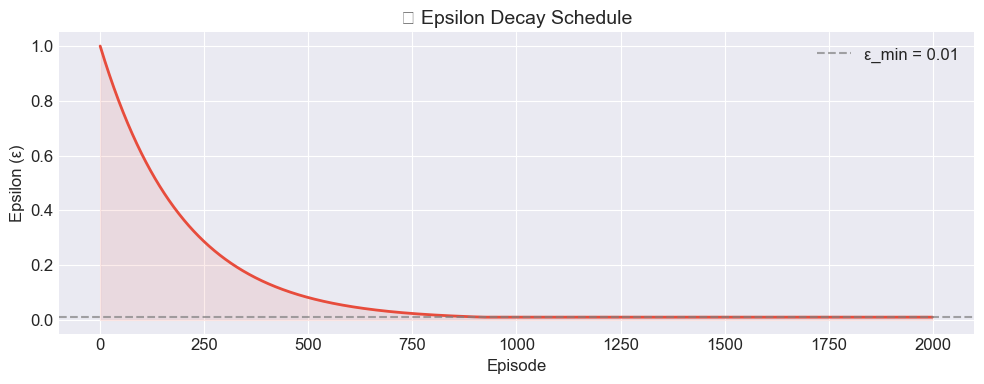

In [25]:
# Visualize Epsilon Decay
epsilons = []
eps = EPS_START
for i in range(N_EPISODES):
    epsilons.append(eps)
    eps = max(EPS_END, EPS_DECAY * eps)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epsilons, color='#e74c3c', linewidth=2)
ax.axhline(y=EPS_END, color='gray', linestyle='--', alpha=0.7, label=f'ε_min = {EPS_END}')
ax.set_xlabel('Episode')
ax.set_ylabel('Epsilon (ε)')
ax.set_title('📉 Epsilon Decay Schedule')
ax.legend()
ax.fill_between(range(N_EPISODES), epsilons, alpha=0.1, color='#e74c3c')
plt.tight_layout()
plt.show()

---
## 5. So sánh và phân tích kết quả

### 5.1 Đường cong học tập (Learning Curves)

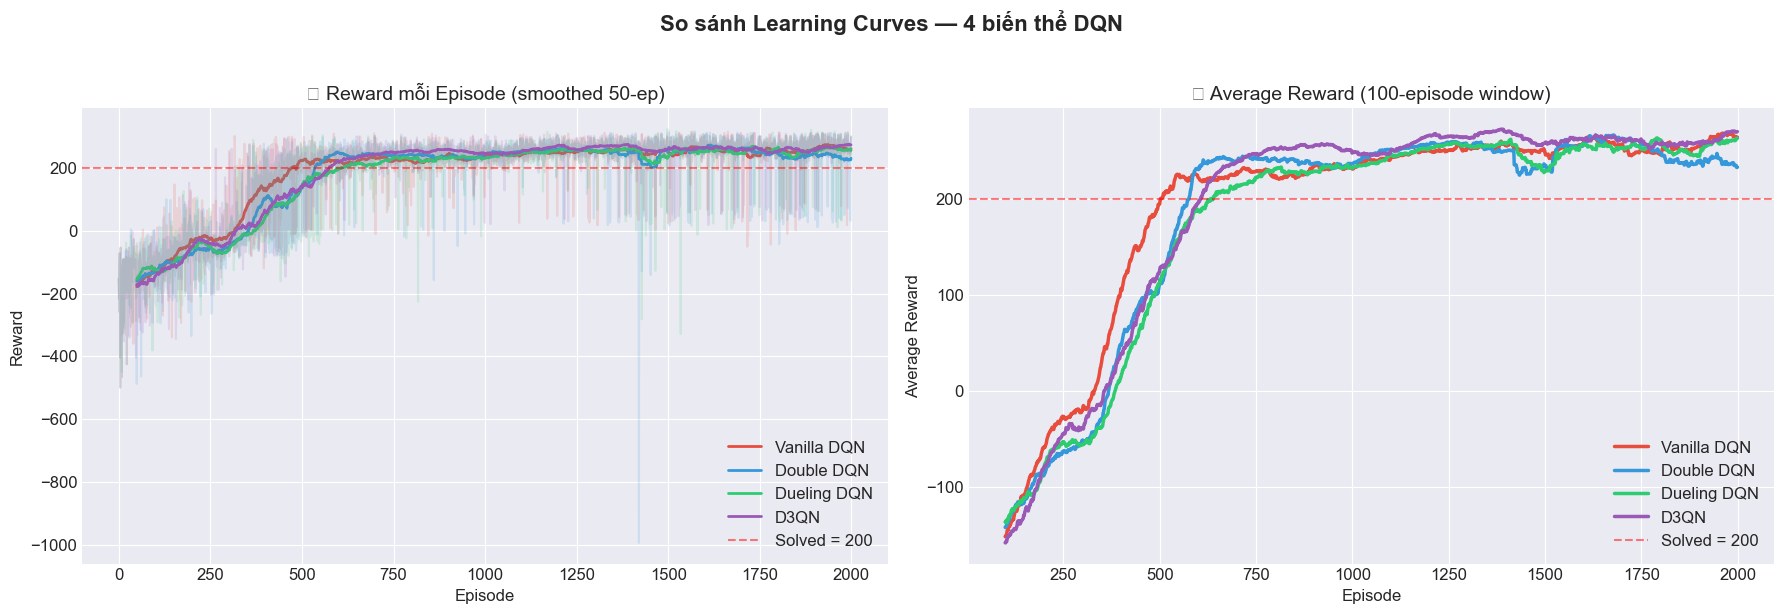

In [26]:
# ===================== LEARNING CURVES =====================
colors = {'Vanilla DQN': '#e74c3c', 'Double DQN': '#3498db',
          'Dueling DQN': '#2ecc71', 'D3QN': '#9b59b6'}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# (A) Raw scores
for name, scores in all_scores.items():
    axes[0].plot(scores, alpha=0.15, color=colors[name])
    # Moving average
    ma = pd.Series(scores).rolling(50).mean()
    axes[0].plot(ma, label=name, color=colors[name], linewidth=2)

axes[0].axhline(y=200, color='red', linestyle='--', alpha=0.5, label='Solved = 200')
axes[0].set_title('🎯 Reward mỗi Episode (smoothed 50-ep)')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Reward')
axes[0].legend(loc='lower right')

# (B) 100-episode moving average
for name, scores in all_scores.items():
    ma100 = pd.Series(scores).rolling(100).mean()
    axes[1].plot(ma100, label=name, color=colors[name], linewidth=2.5)

axes[1].axhline(y=200, color='red', linestyle='--', alpha=0.5, label='Solved = 200')
axes[1].set_title('📊 Average Reward (100-episode window)')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Average Reward')
axes[1].legend(loc='lower right')

plt.suptitle('So sánh Learning Curves — 4 biến thể DQN', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.2 Bảng so sánh chi tiết

In [27]:
# ===================== BẢNG SO SÁNH =====================
results_data = []
for name, scores in all_scores.items():
    last_100 = scores[-100:] if len(scores) >= 100 else scores
    results_data.append({
        'Thuật toán': name,
        'Episodes': len(scores),
        'Solved tại': solved_episodes.get(name, 'N/A'),
        'Avg (last 100)': f"{np.mean(last_100):.2f}",
        'Max Reward': f"{np.max(scores):.2f}",
        'Min Reward': f"{np.min(scores):.2f}",
        'Std (last 100)': f"{np.std(last_100):.2f}",
        'Thời gian (s)': f"{training_times.get(name, 0):.1f}"
    })

df_results = pd.DataFrame(results_data)
print("📋 BẢNG SO SÁNH KẾT QUẢ:")
print("=" * 90)
print(df_results.to_string(index=False))
print("=" * 90)

📋 BẢNG SO SÁNH KẾT QUẢ:
 Thuật toán  Episodes  Solved tại Avg (last 100) Max Reward Min Reward Std (last 100) Thời gian (s)
Vanilla DQN      2000         503         264.66     316.82    -499.16          37.36           0.0
 Double DQN      2000         577         233.30     313.33    -993.90          87.62           0.0
Dueling DQN      2000         633         263.47     324.30    -449.72          50.61           0.0
       D3QN      2000         607         270.47     314.73    -403.67          36.12           0.0


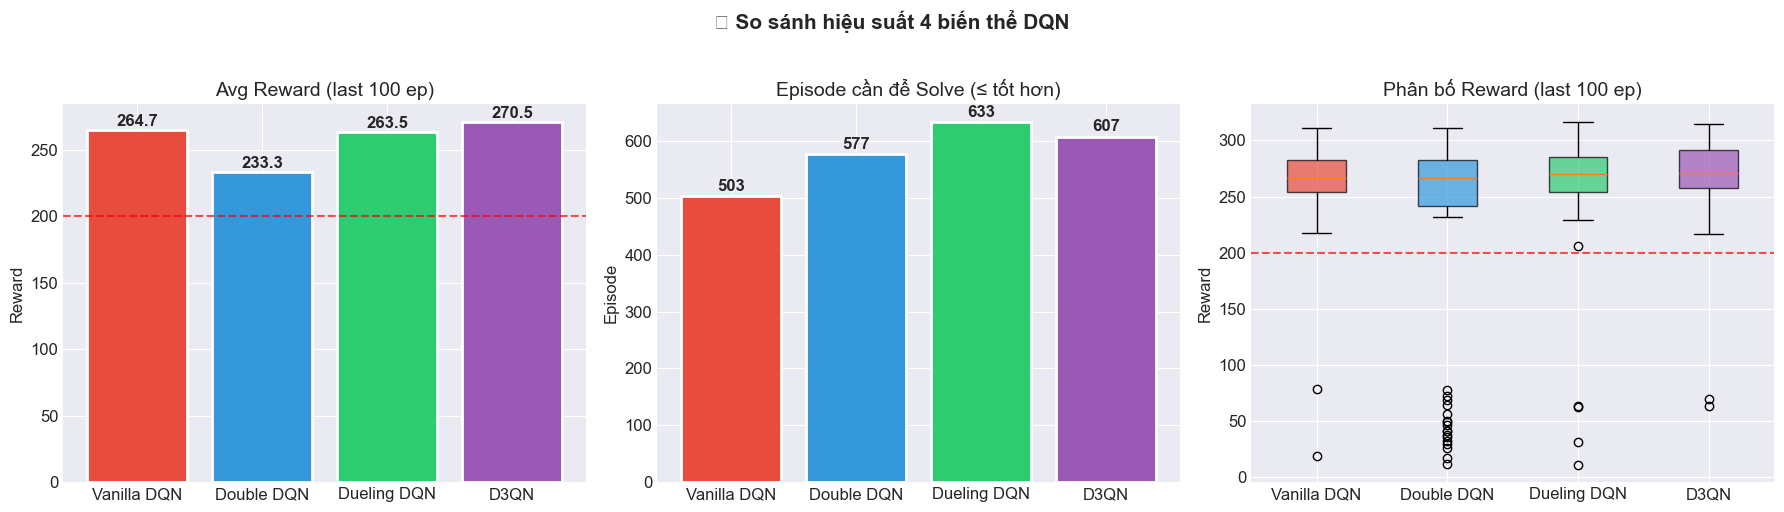

In [28]:
# ===================== BIỂU ĐỒ SO SÁNH =====================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
names = list(all_scores.keys())
color_list = [colors[n] for n in names]

# (A) Average reward (last 100)
avg_rewards = [np.mean(all_scores[n][-100:]) for n in names]
bars1 = axes[0].bar(names, avg_rewards, color=color_list, edgecolor='white', linewidth=2)
axes[0].axhline(y=200, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('Avg Reward (last 100 ep)')
axes[0].set_ylabel('Reward')
for bar, val in zip(bars1, avg_rewards):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
                f'{val:.1f}', ha='center', fontweight='bold')

# (B) Episode to solve
solve_eps = [solved_episodes.get(n, N_EPISODES) or N_EPISODES for n in names]
bars2 = axes[1].bar(names, solve_eps, color=color_list, edgecolor='white', linewidth=2)
axes[1].set_title('Episode cần để Solve (≤ tốt hơn)')
axes[1].set_ylabel('Episode')
for bar, val in zip(bars2, solve_eps):
    label = str(val) if val < N_EPISODES else 'N/A'
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
                label, ha='center', fontweight='bold')

# (C) Boxplot last 100 episodes
box_data = [all_scores[n][-100:] for n in names]
bp = axes[2].boxplot(box_data, labels=names, patch_artist=True)
for patch, color in zip(bp['boxes'], color_list):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].axhline(y=200, color='red', linestyle='--', alpha=0.7)
axes[2].set_title('Phân bố Reward (last 100 ep)')
axes[2].set_ylabel('Reward')

plt.suptitle('📊 So sánh hiệu suất 4 biến thể DQN', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Phân tích và nhận xét

**Nhận xét từ kết quả thí nghiệm:**

1. **Vanilla DQN** là baseline, có thể giải được bài toán nhưng thường chậm hơn và reward dao động nhiều do overestimation bias.

2. **Double DQN** giảm overestimation → Q-values ước lượng chính xác hơn → agent học ổn định hơn, thường solve nhanh hơn Vanilla DQN.

3. **Dueling DQN** tách V(s) và A(s,a) → học hiệu quả hơn giá trị trạng thái, đặc biệt hữu ích khi nhiều hành động có advantage tương đương.

4. **D3QN** kết hợp cả hai → thường cho kết quả **tốt nhất và ổn định nhất**, tận dụng ưu điểm giảm overestimation + kiến trúc hiệu quả.

> **Kết luận:** Các kỹ thuật cải tiến (Double, Dueling) đều giúp cải thiện hiệu suất so với DQN gốc. D3QN thường là lựa chọn tốt nhất.

---
## 6. Đánh giá Agent

Chạy agent đã huấn luyện (greedy policy, ε = 0) trong 100 episode để đánh giá hiệu suất thực tế.

🏆 Đánh giá D3QN Agent (100 episodes, ε=0):
   Mean Reward:  251.04 ± 54.20
   Max Reward:   315.84
   Min Reward:   39.61
   Success Rate: 86.0%


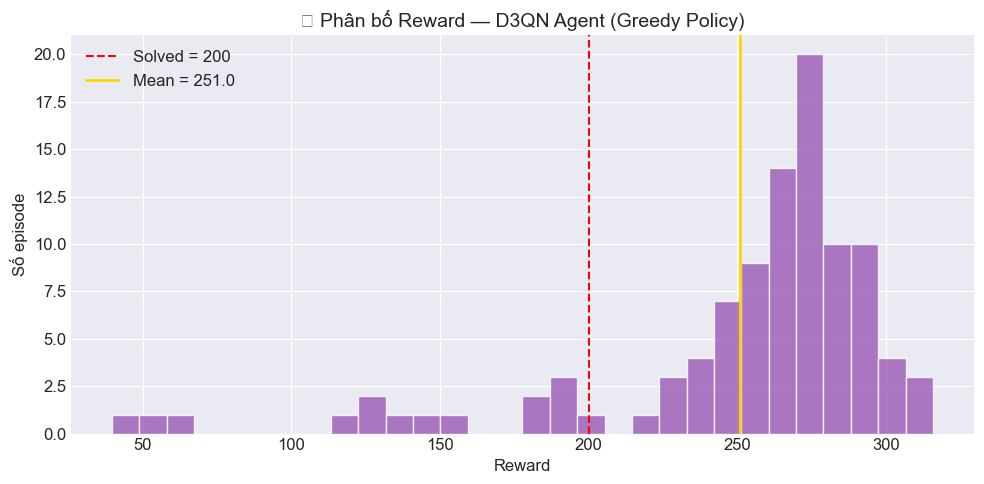

In [29]:
def evaluate_agent(model_path, double_dqn=False, dueling=False, n_eval=100):
    '''Đánh giá agent đã huấn luyện.'''
    env = gym.make('LunarLander-v3')
    state_size = env.observation_space.shape[0]
    action_size = env.action_space.n

    agent = DQNAgent(state_size, action_size, seed=SEED,
                     double_dqn=double_dqn, dueling=dueling)
    agent.qnetwork_local.load_state_dict(torch.load(model_path, map_location=device))

    scores = []
    for i in range(n_eval):
        state, _ = env.reset()
        score = 0
        for t in range(MAX_T):
            action = agent.act(state, eps=0.0)  # Greedy
            state, reward, terminated, truncated, _ = env.step(action)
            score += reward
            if terminated or truncated:
                break
        scores.append(score)
    env.close()
    return scores

# Đánh giá model tốt nhất (D3QN)
best_model = 'results/d3qn_model.pth'
if os.path.exists(best_model):
    eval_scores = evaluate_agent(best_model, double_dqn=True, dueling=True)
    print(f"🏆 Đánh giá D3QN Agent ({len(eval_scores)} episodes, ε=0):")
    print(f"   Mean Reward:  {np.mean(eval_scores):.2f} ± {np.std(eval_scores):.2f}")
    print(f"   Max Reward:   {np.max(eval_scores):.2f}")
    print(f"   Min Reward:   {np.min(eval_scores):.2f}")
    print(f"   Success Rate: {sum(1 for s in eval_scores if s >= 200) / len(eval_scores) * 100:.1f}%")

    # Histogram
    plt.figure(figsize=(10, 5))
    plt.hist(eval_scores, bins=30, color='#9b59b6', edgecolor='white', alpha=0.8)
    plt.axvline(x=200, color='red', linestyle='--', label='Solved = 200')
    plt.axvline(x=np.mean(eval_scores), color='gold', linestyle='-', linewidth=2,
                label=f'Mean = {np.mean(eval_scores):.1f}')
    plt.xlabel('Reward')
    plt.ylabel('Số episode')
    plt.title('🏆 Phân bố Reward — D3QN Agent (Greedy Policy)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Chưa có model. Hãy chạy phần training trước!")

### 6.1 Demo trực quan

Hiển thị một số frame agent hạ cánh:

In [30]:
print("Mở cửa sổ mô phỏng... Vui lòng kiểm tra màn hình Desktop hoặc thanh Taskbar (nếu bị che khuất)!")

if IN_COLAB:
    print("⚠️  Google Colab không hỗ trợ cửa sổ render 'human'. Bỏ qua demo trực quan này.")
else:
    try:
        env_render = gym.make('LunarLander-v3', render_mode='human')
        best_model = 'results/d3qn_model.pth'
        
        if os.path.exists(best_model):
            agent = DQNAgent(8, 4, seed=SEED, double_dqn=True, dueling=True)
            agent.qnetwork_local.load_state_dict(torch.load(best_model, map_location=device))

            state, _ = env_render.reset(seed=42)
            score = 0
            
            for t in range(MAX_T):
                env_render.render()
                
                # Ép hệ điều hành cập nhật giao diện cửa sổ (tránh bị đơ trắng)
                pygame.event.pump() 
                
                action = agent.act(state, eps=0.0)
                state, reward, terminated, truncated, _ = env_render.step(action)
                score += reward
                
                # Làm chậm game lại để dễ nhìn (50ms = 20 FPS)
                time.sleep(0.05) 
                
                if terminated or truncated:
                    env_render.render()
                    # Dừng lại 2 giây ở màn hình cuối trước khi tắt để bạn kịp xem
                    time.sleep(2)
                    break

            env_render.close()
            print(f'🎮 Demo hoàn tất — Total Reward: {score:.1f}')
            
        else:
            print("⚠️  Chưa có model D3QN. Hãy chạy training trước!")
    except Exception as e:
        print(f"⚠️  Lỗi khi hiển thị cửa sổ: {e}")


Mở cửa sổ mô phỏng... Vui lòng kiểm tra màn hình Desktop hoặc thanh Taskbar (nếu bị che khuất)!
🎮 Demo hoàn tất — Total Reward: 261.2


---
## 7. Kết luận

### 7.1 Tổng kết

Bài tập đã triển khai và so sánh **4 biến thể DQN** trên môi trường LunarLander-v3:

- **Vanilla DQN:** Baseline, áp dụng Experience Replay + Target Network
- **Double DQN:** Giảm overestimation bằng cách tách chọn hành động & đánh giá
- **Dueling DQN:** Kiến trúc tách V(s) và A(s,a) giúp học hiệu quả hơn
- **D3QN:** Kết hợp cả hai kỹ thuật, thường cho kết quả tốt nhất

Các kỹ thuật bổ trợ: **Experience Replay**, **Target Network (soft update)**, **ε-greedy exploration**, **Gradient Clipping**.

### 7.2 Hướng phát triển

- **Prioritized Experience Replay (PER):** Ưu tiên sample các experience có TD-error lớn
- **Noisy Networks:** Thay ε-greedy bằng nhiễu tham số mạng
- **Rainbow DQN:** Kết hợp tất cả cải tiến (Double + Dueling + PER + Noisy + N-step + Distributional)
- **Policy Gradient / Actor-Critic:** So sánh với các thuật toán khác họ (A2C, PPO, SAC)

---
## 8. Tài liệu tham khảo

1. Mnih, V. et al. (2015). *Human-level control through deep reinforcement learning*. Nature.
2. van Hasselt, H. et al. (2016). *Deep Reinforcement Learning with Double Q-learning*. AAAI.
3. Wang, Z. et al. (2016). *Dueling Network Architectures for Deep Reinforcement Learning*. ICML.
4. Schaul, T. et al. (2016). *Prioritized Experience Replay*. ICLR.
5. Sutton, R. & Barto, A. (2018). *Reinforcement Learning: An Introduction*. MIT Press.
6. OpenAI Gymnasium Documentation: https://gymnasium.farama.org/